In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configure file paths

# Human TF promoter-level chec-seq binding signal
chec_sumprom_pattern = "sumproms/*.gz"

# Motif binding score directory (see analysis code for calculation)
binding_score_base_dir = "binding_score_at_motifs"
representative_regex = "__*loc-prom__*family*__fl25__*.csv"

## Imports

In [3]:
import glob
from itertools import combinations

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Helper Functions

In [4]:
# Keep only reproducible replicate columns within each sample group
def filter_reproducible(sumprom_all: pd.DataFrame, cutoff: float) -> pd.DataFrame:
    df = sumprom_all.copy()
    groups = pd.Series(df.columns, index=df.columns).str.rsplit("_", n=2).str[0]

    keep = []
    for _, members in groups.groupby(groups).groups.items():
        if len(members) < 2:
            continue
        corr = df[members].corr()
        np.fill_diagonal(corr.values, np.nan)
        max_corrs = corr.max(axis=1)
        reproducible = max_corrs[max_corrs >= cutoff].index.tolist()
        keep.extend(reproducible)

    return df[keep]


# Load the representative motif-binding table for one sample
def load_sample(sample_name: str, regex_search: str):
    df_files = glob.glob(
        f"{binding_score_base_dir}/{sample_name}/{sample_name}{regex_search}"
    )
    if len(df_files) != 1:
        return None

    bg_files = glob.glob(
        f"{binding_score_base_dir}/background_binding_arrays/"
        f"{sample_name}__*__loc-prom__signal_bg__fl25*.npy"
    )
    if len(bg_files) != 1:
        return None

    return pd.read_csv(df_files[0])


# Get replicate columns that belong to one sample
def get_sample_replicate_cols(sumprom_filtered: pd.DataFrame, sample: str):
    return [c for c in sumprom_filtered.columns if "_".join(c.split("_")[:-2]) == sample]


## Data Loading

In [5]:
# Load promoter-level signal tables from all sequencing rounds
sumprom_all = pd.concat([pd.read_parquet(x) for x in glob.glob(chec_sumprom_pattern)], axis=1,)

# Keep only reproducible samples
corr_cutoff = 0.895
sumprom_filtered = filter_reproducible(sumprom_all, cutoff=corr_cutoff)

# Keep at most the best three replicates per sample, matching the original notebook
cols = pd.Index(sumprom_filtered.columns)
prefix = cols.to_series().str.rsplit("_", n=2).str[0]
best3 = lambda g: list(g) if len(g) <= 3 else max(combinations(g, 3), key=lambda c: sumprom_filtered.loc[:, c].corr().to_numpy()[np.triu_indices(3, 1)].sum(),)
sumprom_filtered = sumprom_filtered.loc[:,cols.to_series().groupby(prefix).apply(best3).explode(),]

# Keep only the ERG swap family used in this plot
erg_swaps = ["ERG", "ELF1", "ERG_DBD_ELF1"]
dbd_fam_dict = {"erg_swaps": erg_swaps}

cols_to_keep = set(sum(dbd_fam_dict.values(), []))
sample_prefix = sumprom_filtered.columns.to_series().str.rsplit("_", n=2).str[0]
sumprom_filtered = sumprom_filtered.loc[:, sample_prefix.isin(cols_to_keep).values]

# Load representative motif-binding tables for the same samples
df_dict_representative = {}
for sample in erg_swaps:
    df_dict_representative[sample] = load_sample(sample, representative_regex)

## Plot

In [6]:
# Plot combined binding + replicate correlation heatmap per family
def plot_family_heatmaps(
    dbd_fam_dict,
    sumprom_filtered,
    df_dict_representative,
    annotate=False,
    figsize=None,
):
    # Required columns for a valid binding table
    def _is_valid_binding_df(df):
        need = {"motif_id", "sequence_name", "start", "z_score_norm_f7"}
        return isinstance(df, pd.DataFrame) and need.issubset(df.columns)

    # Rename selected samples for display
    display_name = {
        "ERG_DBD_ELF1": "ERG-DBD\nELF1-nonDBD",
    }

    for fam, samples in dbd_fam_dict.items():
        # Keep samples that have both binding data and replicate signal columns
        kept, reps = [], {}
        for s in samples:
            df = df_dict_representative.get(s, None)
            cols = sorted(get_sample_replicate_cols(sumprom_filtered, s))
            if _is_valid_binding_df(df) and len(cols) > 0:
                kept.append(s)
                reps[s] = cols

        if len(kept) < 2:
            continue

        # Sample-level binding correlation across matched motif hits
        wide = {}
        for s in kept:
            df = df_dict_representative[s]
            wide[s] = df.set_index(
                ["motif_id", "sequence_name", "start"]
            )["z_score_norm_f7"]
        bind_corr = pd.concat(wide, axis=1).corr()

        # Cluster samples by binding similarity
        try:
            from scipy.cluster.hierarchy import leaves_list, linkage
            from scipy.spatial.distance import squareform

            D = 1.0 - bind_corr.values
            np.fill_diagonal(D, 0.0)
            Z = linkage(squareform(D, checks=False), method="average")
            kept = [kept[i] for i in leaves_list(Z)]
            bind_corr = bind_corr.loc[kept, kept]
        except Exception:
            pass

        # Replicate-level promoter-signal correlation
        all_rep_cols = [c for s in kept for c in reps[s]]
        rep_corr = sumprom_filtered[all_rep_cols].corr()

        bind_corr = bind_corr.clip(lower=0)
        rep_corr = rep_corr.clip(lower=0)

        n = len(kept)
        scale = 100
        size = max(4.0, n * 0.65)

        if figsize is None:
            fig, ax = plt.subplots(figsize=(size, size))
        else:
            fig, ax = plt.subplots(figsize=figsize)

        img = np.full((n * scale, n * scale), np.nan)

        # Diagonal blocks:
        # lower triangle = 1
        # upper triangle = within-sample replicate correlation
        for i, si in enumerate(kept):
            yS, yE = i * scale, (i + 1) * scale
            xS, xE = i * scale, (i + 1) * scale

            block = np.full((scale, scale), np.nan)
            tri = np.tri(scale, scale, k=0, dtype=bool)
            block[tri] = 1.0

            ri = reps[si]
            ni = len(ri)
            if ni >= 1:
                for a, ca in enumerate(ri):
                    for b, cb in enumerate(ri):
                        if a <= b:
                            v = 1.0 if a == b else rep_corr.loc[ca, cb]
                            y0 = int(a * scale / ni)
                            y1 = int((a + 1) * scale / ni)
                            x0 = int(b * scale / ni)
                            x1 = int((b + 1) * scale / ni)

                            yy, xx = np.ogrid[y0:y1, x0:x1]
                            mask_upper = xx > yy
                            block[y0:y1, x0:x1][mask_upper] = v

            img[yS:yE, xS:xE] = block

        # Bottom-left blocks: sample-level binding correlation
        for i, si in enumerate(kept):
            for j, sj in enumerate(kept):
                if i > j:
                    img[i * scale:(i + 1) * scale, j * scale:(j + 1) * scale] = bind_corr.loc[si, sj]

        # Top-right blocks: replicate-level correlation between samples
        for i, si in enumerate(kept):
            ri, ni = reps[si], len(reps[si])
            for j, sj in enumerate(kept):
                if i < j:
                    rj, nj = reps[sj], len(reps[sj])
                    for a, ca in enumerate(ri):
                        for b, cb in enumerate(rj):
                            v = rep_corr.loc[ca, cb]
                            y0 = int(i * scale + a * scale / ni)
                            y1 = int(i * scale + (a + 1) * scale / ni)
                            x0 = int(j * scale + b * scale / nj)
                            x1 = int(j * scale + (b + 1) * scale / nj)
                            img[y0:y1, x0:x1] = v

        # Draw the heatmap with explicit cell edges so the grid matches exactly
        x_edges = np.arange(n * scale + 1) - 0.5
        y_edges = np.arange(n * scale + 1) - 0.5

        pcm = ax.pcolormesh(
            x_edges,
            y_edges,
            img,
            cmap="Reds",
            vmin=0.55,
            vmax=1,
            shading="flat",
        )

        # Keep the same visual orientation as before
        ax.set_xlim(-0.5, n * scale - 0.5)
        ax.set_ylim(n * scale - 0.5, -0.5)
        ax.set_aspect("auto")

        # Main sample grid
        for k in range(n + 1):
            p = k * scale - 0.5
            ax.axhline(p, color="black", linewidth=0.9)
            ax.axvline(p, color="black", linewidth=0.9)

        # Replicate grid in off-diagonal top-right blocks
        for i, si in enumerate(kept):
            for j, sj in enumerate(kept):
                if i < j:
                    ni, nj = len(reps[si]), len(reps[sj])

                    for a in range(1, ni):
                        y = i * scale + a * scale / ni - 0.5
                        ax.plot(
                            [j * scale - 0.5, (j + 1) * scale - 0.5],
                            [y, y],
                            color="black",
                            linewidth=0.4,
                        )

                    for b in range(1, nj):
                        x = j * scale + b * scale / nj - 0.5
                        ax.plot(
                            [x, x],
                            [i * scale - 0.5, (i + 1) * scale - 0.5],
                            color="black",
                            linewidth=0.4,
                        )

        # Replicate grid inside diagonal blocks, clipped to upper triangle
        for i, si in enumerate(kept):
            ni = len(reps[si])
            if ni <= 1:
                continue

            xS, yS = i * scale - 0.5, i * scale - 0.5
            xE = (i + 1) * scale - 0.5

            for a in range(1, ni):
                y = i * scale + a * scale / ni - 0.5
                ax.plot([xS + (y - yS), xE], [y, y], color="black", linewidth=0.4)

            for b in range(1, ni):
                x = i * scale + b * scale / ni - 0.5
                ax.plot([x, x], [yS, yS + (x - xS)], color="black", linewidth=0.4)

        if annotate:
            fs = 5

            for i, si in enumerate(kept):
                for j, sj in enumerate(kept):
                    if i > j:
                        v = float(bind_corr.loc[si, sj])
                        ax.text(
                            j * scale + scale / 2 - 0.5,
                            i * scale + scale / 2 - 0.5,
                            f"{v:.2f}",
                            ha="center",
                            va="center",
                            fontsize=fs,
                        )

            for i, si in enumerate(kept):
                ri, ni = reps[si], len(reps[si])
                for j, sj in enumerate(kept):
                    if i < j:
                        rj, nj = reps[sj], len(reps[sj])
                        for a, ca in enumerate(ri):
                            for b, cb in enumerate(rj):
                                v = float(rep_corr.loc[ca, cb])
                                y0 = i * scale + a * scale / ni - 0.5
                                y1 = i * scale + (a + 1) * scale / ni - 0.5
                                x0 = j * scale + b * scale / nj - 0.5
                                x1 = j * scale + (b + 1) * scale / nj - 0.5
                                ax.text(
                                    (x0 + x1) / 2,
                                    (y0 + y1) / 2,
                                    f"{v:.2f}",
                                    ha="center",
                                    va="center",
                                    fontsize=fs,
                                )

            for i, si in enumerate(kept):
                ri, ni = reps[si], len(reps[si])
                ax.text(
                    i * scale + scale / 2 - 0.5,
                    i * scale + scale / 2 - 0.5,
                    f"{1.00:.2f}",
                    ha="center",
                    va="center",
                    fontsize=fs,
                )

                for a, ca in enumerate(ri):
                    for b, cb in enumerate(ri):
                        if a <= b:
                            v = 1.0 if a == b else float(rep_corr.loc[ca, cb])
                            y0 = i * scale + a * scale / ni - 0.5
                            y1 = i * scale + (a + 1) * scale / ni - 0.5
                            x0 = i * scale + b * scale / ni - 0.5
                            x1 = i * scale + (b + 1) * scale / ni - 0.5

                            if (x0 + x1) / 2 > (y0 + y1) / 2:
                                ax.text(
                                    (x0 + x1) / 2,
                                    (y0 + y1) / 2,
                                    f"{v:.2f}",
                                    ha="center",
                                    va="center",
                                    fontsize=fs,
                                )

        # Main diagonal
        ax.plot([-0.5, n * scale - 0.5], [-0.5, n * scale - 0.5], color="black", linewidth=1.1)

        # Sample labels
        centers = np.arange(n) * scale + scale / 2 - 0.5
        labels = [display_name.get(s, s) for s in kept]

        ax.set_xticks(centers)
        ax.set_yticks(centers)
        ax.set_xticklabels(labels, rotation=0, fontsize=10)
        ax.set_yticklabels(labels, rotation=90, fontsize=10, va="center", ha="center")
        ax.tick_params(axis="y", pad=15)

        for t in ax.get_yticklabels():
            t.set_multialignment("center")

        ax.tick_params(length=0, labelsize=12)
        for spine in ax.spines.values():
            spine.set_visible(False)

        # Colorbar with 0.1 spacing
        pos = ax.get_position()
        cax = fig.add_axes([
            pos.x1 + 0.01,
            pos.y0,
            0.04,
            pos.height,
        ])
        cb = fig.colorbar(pcm, cax=cax, ticks=np.arange(0.6, 1.01, 0.1))
        cb.set_label("Correlation", fontsize=14, rotation=270, labelpad=14)
        cb.ax.tick_params(labelsize=12)

        plt.show()

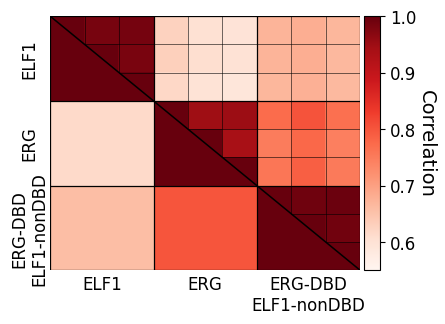

In [7]:
# Plot the ERG swap family heatmap
plot_family_heatmaps(
    dbd_fam_dict,
    sumprom_filtered,
    df_dict_representative,
    annotate=False,
    figsize=(4, 3.3),
)